In [1]:
# ============================================================
# 0. Imports & Configuration
# ============================================================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal
from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis, skew

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

FS = 2000
DATA_DIR = Path("/home/mamunds/job/pyspark/konux/data")


In [2]:
# ============================================================
# 1. Helper Functions
# ============================================================

def load_binary_signal(filepath):
    return np.fromfile(filepath, dtype=np.float32)

def parse_filename_metadata(filename):
    meta = {}
    m = re.match(r"(\d{8})_(\d{6})_(\d+)_", filename)
    if m:
        meta["date"], meta["time"], meta["sensor_id"] = m.groups()
    return meta

def bandpass_filter_zero_phase(x, fs, low=5, high=500, order=4):
    x = x - np.mean(x)
    b, a = signal.butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return signal.filtfilt(b, a, x)

def rms_envelope(x, fs, window_s=0.05):
    w = max(1, int(window_s * fs))
    return np.sqrt(np.convolve(x**2, np.ones(w)/w, mode="same"))

def segment_active_region(env, fs):
    baseline = env[:int(0.5*fs)]
    thr = np.mean(baseline) + 3*np.std(baseline)
    idx = np.where(env > thr)[0]
    if len(idx) == 0:
        return 0, len(env)
    return idx[0], idx[-1]


In [3]:
# ============================================================
# 2. FEATURE EXTRACTION (EXTENDED & IMPROVED)
# ============================================================

def extract_time_features(x, fs):
    peaks, _ = signal.find_peaks(np.abs(x), height=np.std(x))

    rms = np.sqrt(np.mean(x**2))
    peak_val = np.max(np.abs(x))

    return {
        # Existing
        "rms": rms,
        "peak_to_peak": np.max(x) - np.min(x),
        "num_peaks": len(peaks),
        "mean_peak_interval_s": np.mean(np.diff(peaks))/fs if len(peaks) > 1 else np.nan,

        # NEW (recommended)
        "variance": np.var(x),
        "crest_factor": peak_val / rms if rms > 0 else np.nan,
        "kurtosis": kurtosis(x),
        "skewness": skew(x),
    }

def band_energy(xf, yf, fmin, fmax):
    m = (xf >= fmin) & (xf < fmax)
    return np.sum(yf[m]**2)

def extract_frequency_features(x, fs):
    yf = np.abs(rfft(x))
    xf = rfftfreq(len(x), 1/fs)

    if np.sum(yf) == 0:
        return {}

    centroid = np.sum(xf * yf) / np.sum(yf)
    bandwidth = np.sqrt(np.sum(((xf - centroid)**2) * yf) / np.sum(yf))

    p = yf / np.sum(yf)
    spectral_entropy = -np.sum(p * np.log(p + 1e-12))

    return {
        # Existing
        "spectral_centroid_hz": centroid,
        "dominant_frequency_hz": xf[np.argmax(yf)],

        # NEW (recommended)
        "spectral_bandwidth_hz": bandwidth,
        "spectral_entropy": spectral_entropy,
        "energy_5_50": band_energy(xf, yf, 5, 50),
        "energy_50_200": band_energy(xf, yf, 50, 200),
        "energy_200_500": band_energy(xf, yf, 200, 500),
    }


In [4]:
# ============================================================
# 3. Load Data & Metadata
# ============================================================

signals = {}
rows = []

for fp in DATA_DIR.glob("*.bin"):
    x = load_binary_signal(fp)
    signals[fp.name] = x
    meta = parse_filename_metadata(fp.name)
    rows.append({
        "file": fp.name,
        **meta,
        "duration_s": len(x) / FS
    })

meta_df = pd.DataFrame(rows).set_index("file")
meta_df


,date,time,sensor_id,duration_s
file,,,,
20220517_122558_080808_001_channel1.bin,20220517,122558,080808,8.0
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,20.0
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,12.0
20220521_121352_079966_001_channel1.bin,20220521,121352,079966,8.0
20220517_120716_058309_001_channel1.bin,20220517,120716,058309,6.0
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,17.0
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,7.0
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,8.0
20220521_121722_079966_001_channel1.bin,20220521,121722,079966,12.0


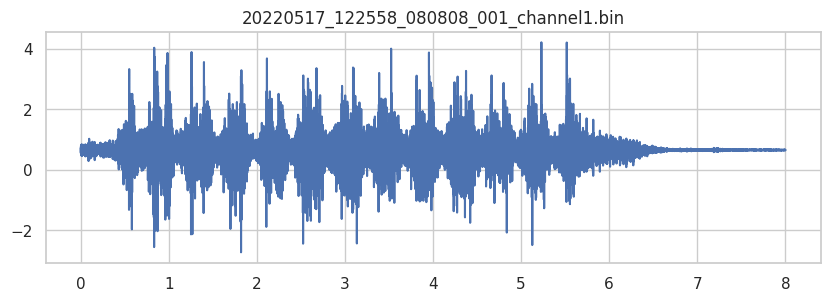

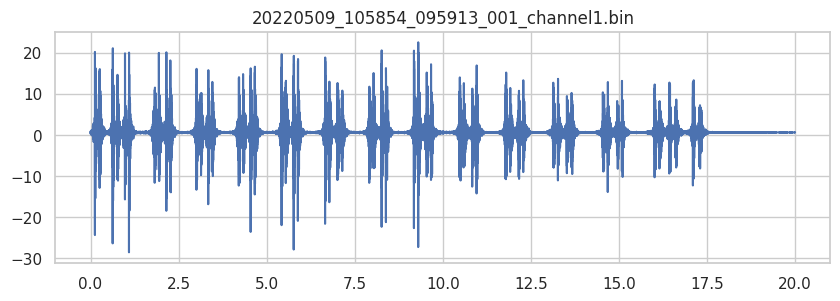

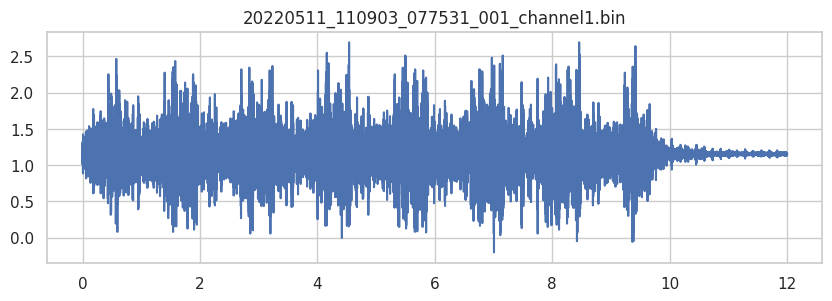

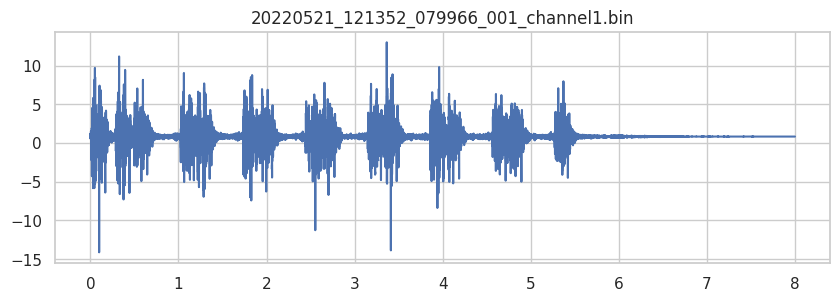

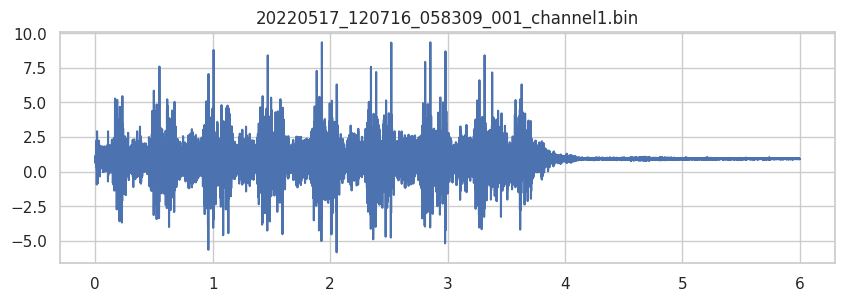

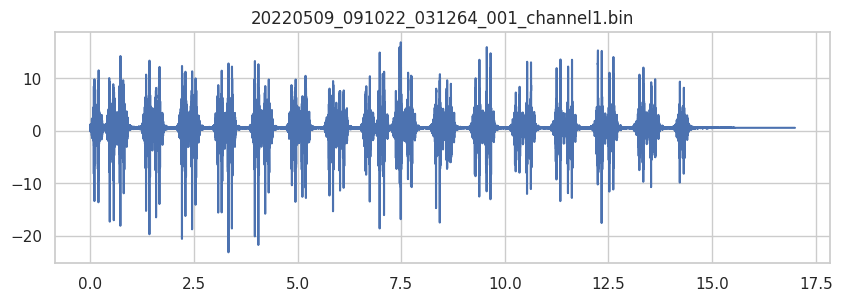

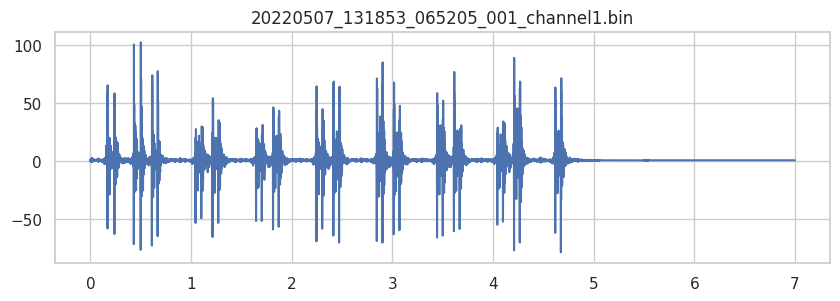

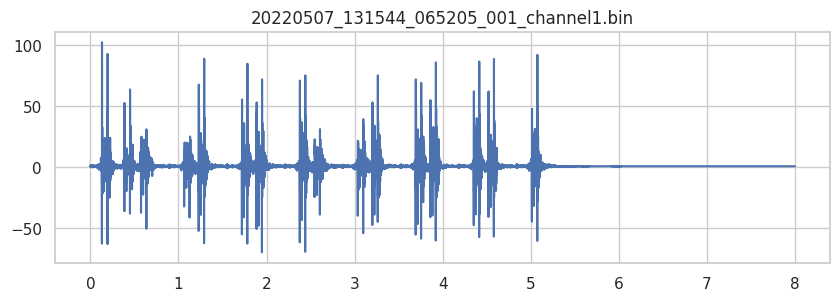

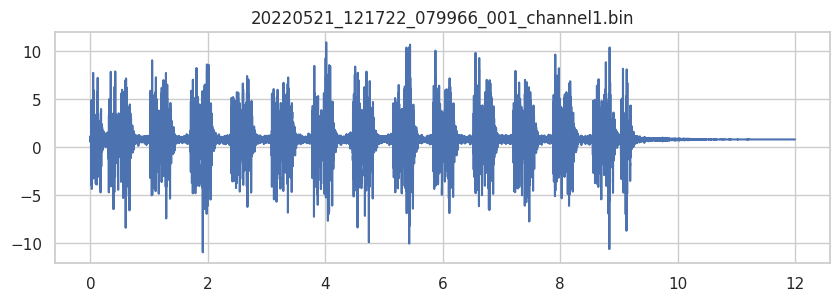

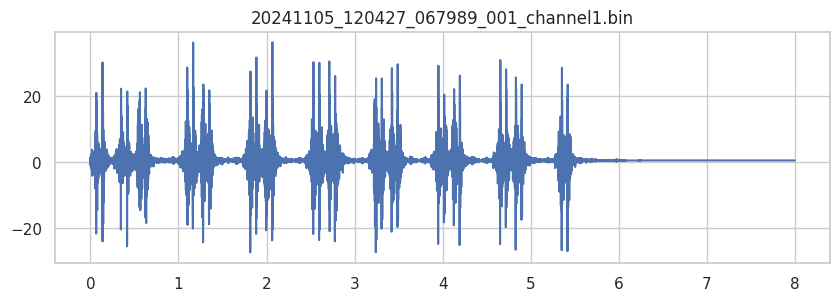

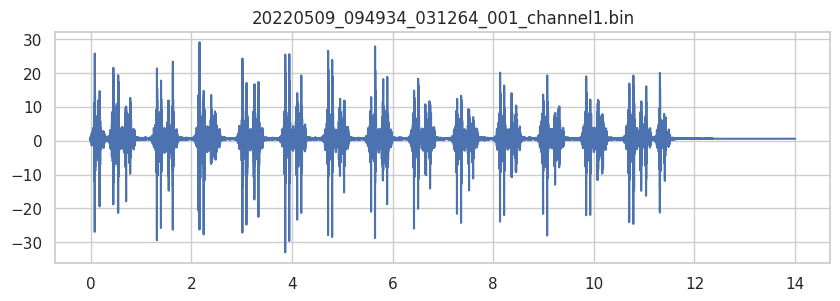

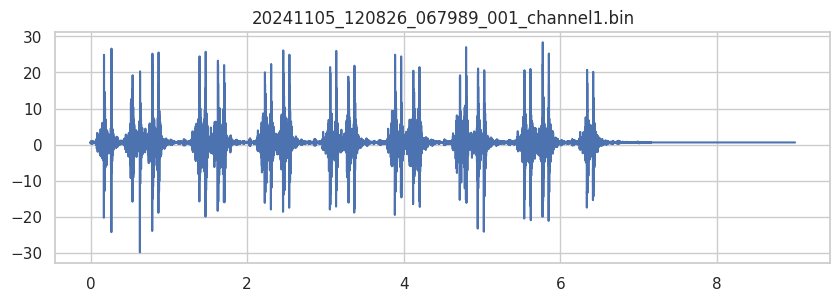

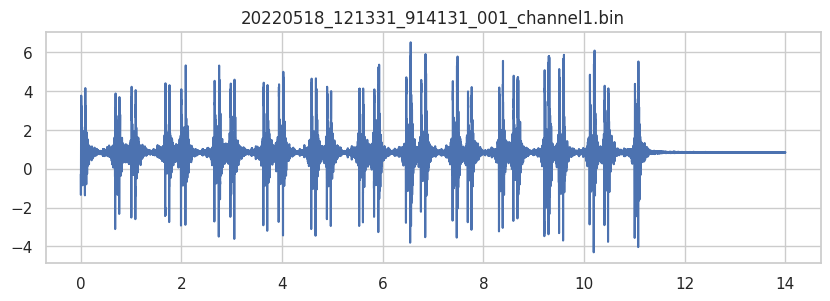

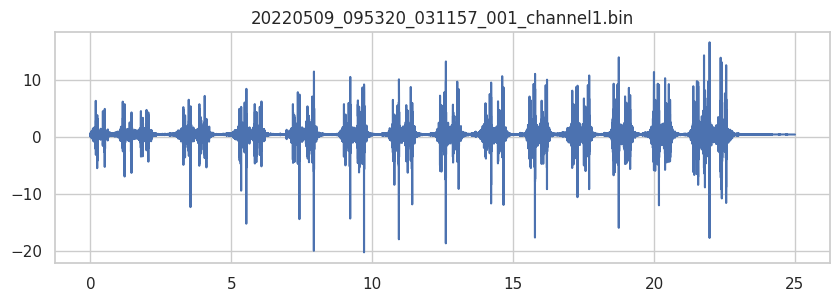

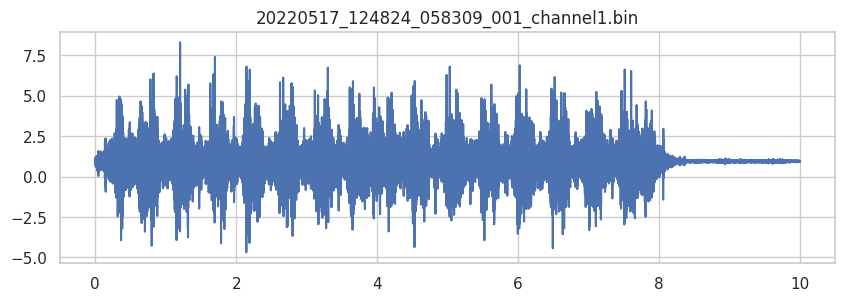

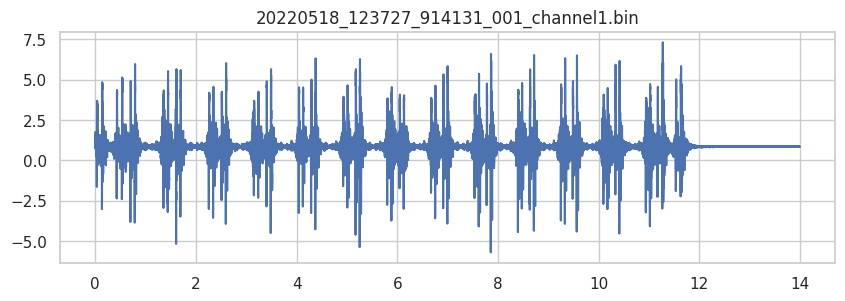

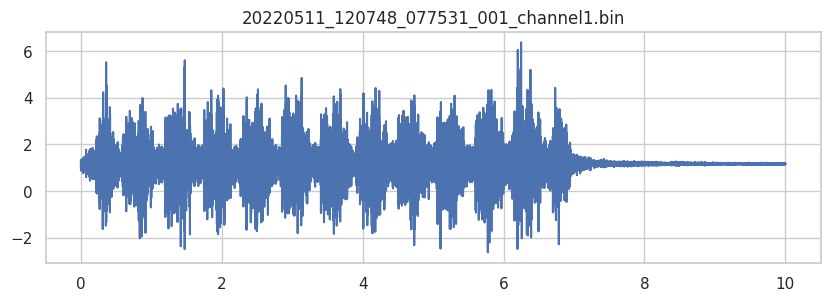

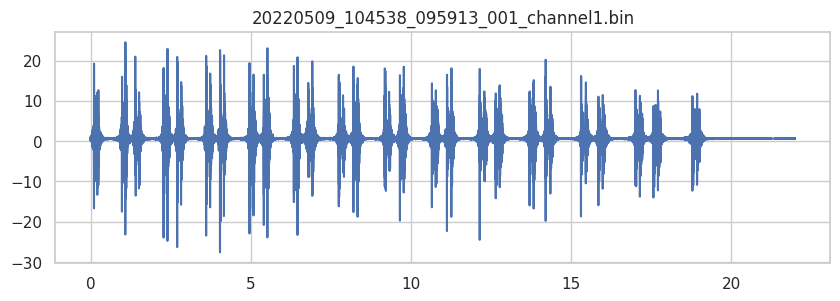

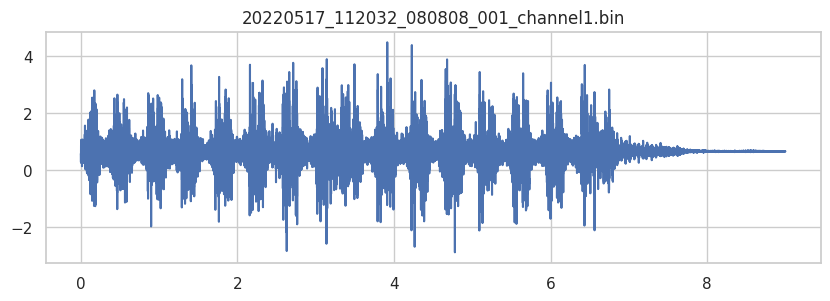

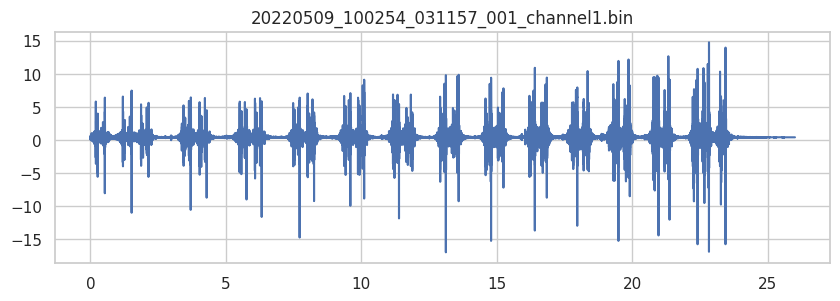

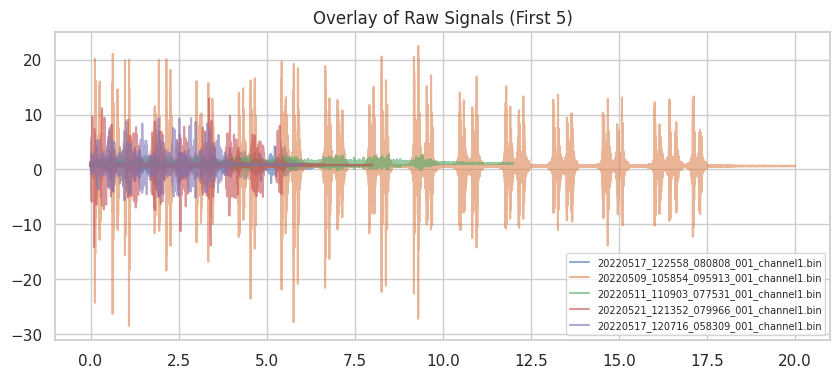

In [5]:
# ============================================================
# 4. Raw Signal Exploration
# ============================================================

for fname, x in signals.items():
    t = np.arange(len(x)) / FS
    plt.figure(figsize=(10,3))
    plt.plot(t, x)
    plt.title(fname)
    plt.grid(True)
    plt.show()

# Overlay
plt.figure(figsize=(10,4))
for fname in list(signals.keys())[:5]:
    x = signals[fname]
    t = np.arange(len(x)) / FS
    plt.plot(t, x, alpha=0.6, label=fname)

plt.title("Overlay of Raw Signals (First 5)")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()


In [6]:
# ============================================================
# 5. Preprocessing & Segmentation
# ============================================================

signals_filt = {}
segments = {}

for fname, x in signals.items():
    xf = bandpass_filter_zero_phase(x, FS)
    env = rms_envelope(xf, FS)
    s, e = segment_active_region(env, FS)

    signals_filt[fname] = xf
    segments[fname] = (s, e)


In [7]:
# ============================================================
# 6. Feature Extraction (FINAL)
# ============================================================

rows = []

for fname in meta_df.index:
    s, e = segments[fname]
    xseg = signals_filt[fname][s:e]

    feats = {}
    feats.update(parse_filename_metadata(fname))
    feats.update(extract_time_features(xseg, FS))
    feats.update(extract_frequency_features(xseg, FS))
    feats["active_duration_s"] = (e - s) / FS
    feats["file"] = fname

    rows.append(feats)

features_df = pd.DataFrame(rows).set_index("file")
features_df


,date,time,sensor_id,rms,peak_to_peak,num_peaks,mean_peak_interval_s,variance,crest_factor,kurtosis,skewness,spectral_centroid_hz,dominant_frequency_hz,spectral_bandwidth_hz,spectral_entropy,energy_5_50,energy_50_200,energy_200_500,active_duration_s
file,,,,,,,,,,,,,,,,,,,
20220517_122558_080808_001_channel1.bin,20220517,122558,080808,0.471155,5.744728,1167,0.004371,0.221987,6.608679,3.433789,0.261289,267.979824,21.174395,154.902739,7.786708,1.576425e+06,3.387047e+06,6.401748e+06,5.1005
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,1.570273,44.038942,1716,0.010048,2.465756,15.778270,35.793564,-0.767909,275.537639,153.950000,147.904191,9.147367,5.241887e+07,7.823284e+08,1.058061e+09,20.0000
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,0.274914,2.739692,2632,0.003360,0.075578,5.293995,1.342806,0.116625,281.152262,42.849067,144.655404,8.001703,1.207123e+06,2.442550e+06,8.168026e+06,8.8450
20220521_121352_079966_001_channel1.bin,20220521,121352,079966,1.113906,21.922877,997,0.005470,1.240778,11.188470,11.669400,-0.598958,242.206566,73.500000,148.063550,8.133067,1.457337e+07,8.012199e+07,6.298641e+07,8.0000
20220517_120716_058309_001_channel1.bin,20220517,120716,058309,0.986060,12.799808,375,0.006274,0.972309,7.498115,9.870996,0.829679,281.614718,93.231162,158.363059,6.907965,1.510237e+06,3.206946e+06,5.767694e+06,2.3490
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,1.490862,33.531185,2027,0.007091,2.222669,12.078250,21.874660,-0.336811,270.079287,195.058824,145.863715,8.884932,1.485902e+07,5.798500e+08,6.831385e+08,17.0000
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,6.829386,153.924298,510,0.008943,46.640509,11.281519,34.356516,-0.773819,269.302788,71.714286,141.620713,8.014900,1.119752e+08,1.798520e+09,2.616725e+09,7.0000
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,6.119571,147.311505,583,0.008562,37.449145,12.986165,42.906549,-0.029624,268.039206,65.375000,136.280171,8.122452,1.192286e+08,1.537899e+09,3.102159e+09,8.0000
20220521_121722_079966_001_channel1.bin,20220521,121722,079966,1.497176,18.834176,555,0.006267,2.241535,6.648112,5.332777,-0.312266,254.132015,92.842771,167.010887,7.362115,4.567290e+06,2.643657e+07,2.291758e+07,3.4790


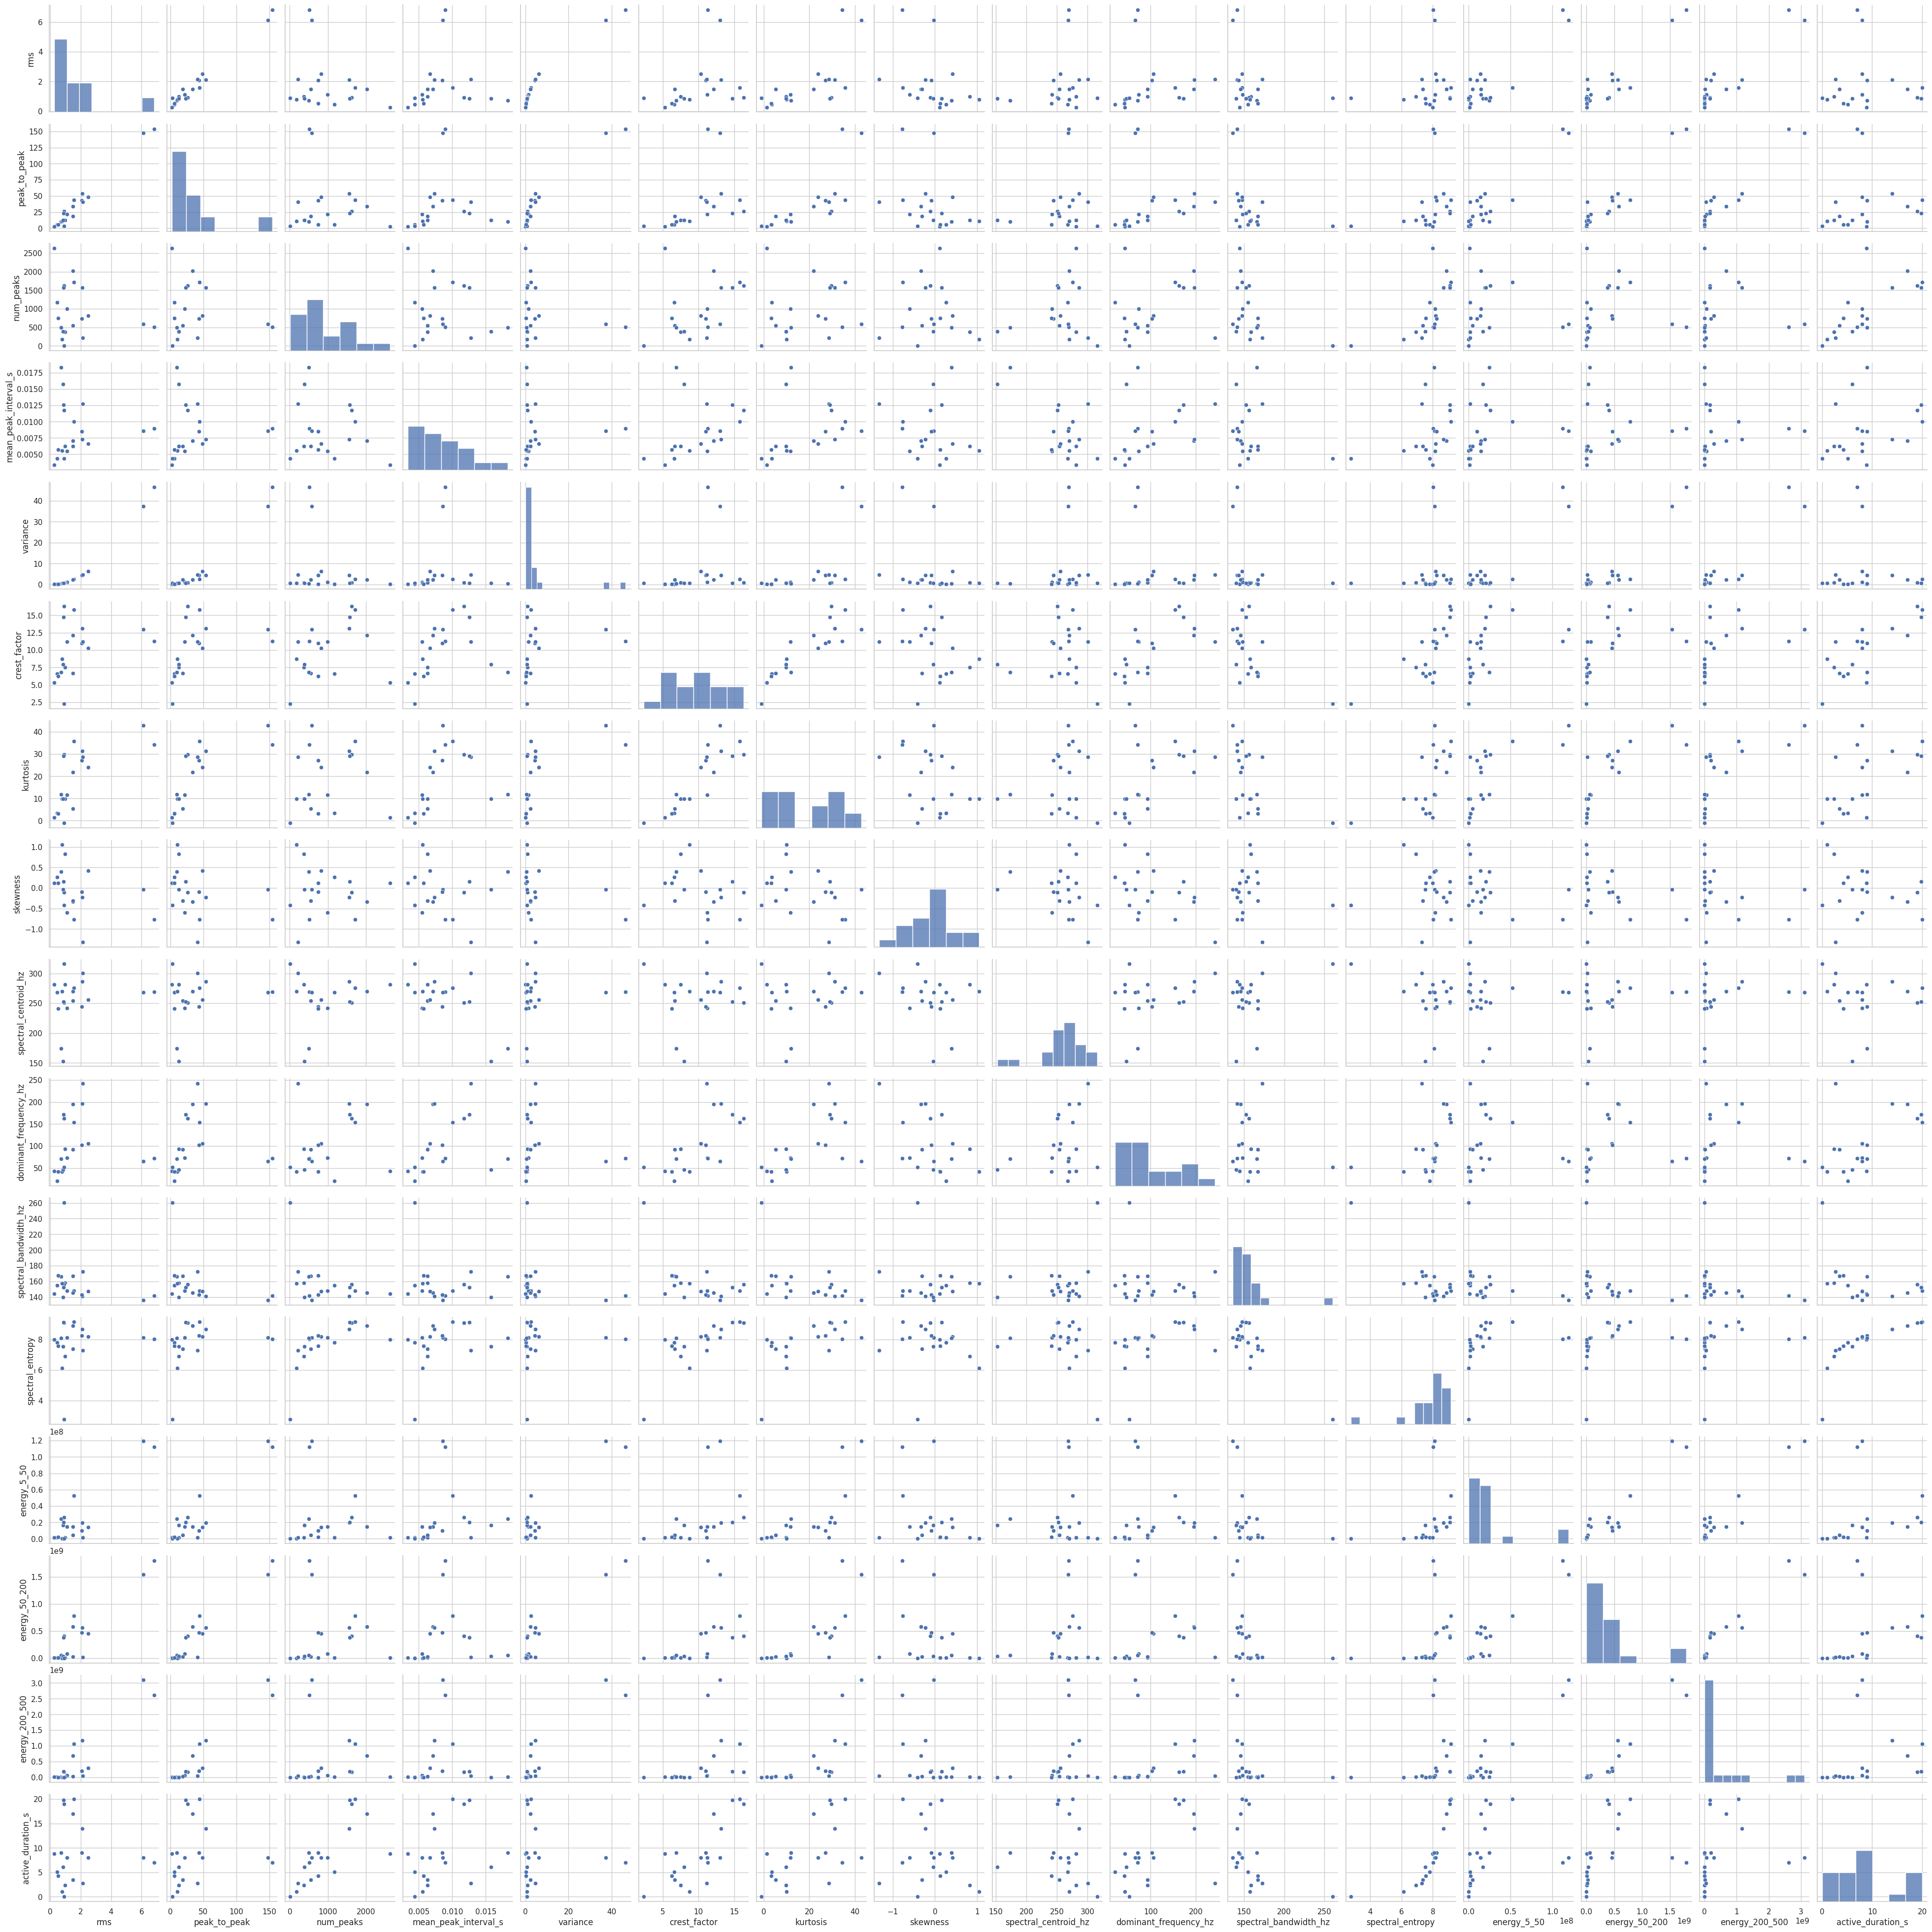

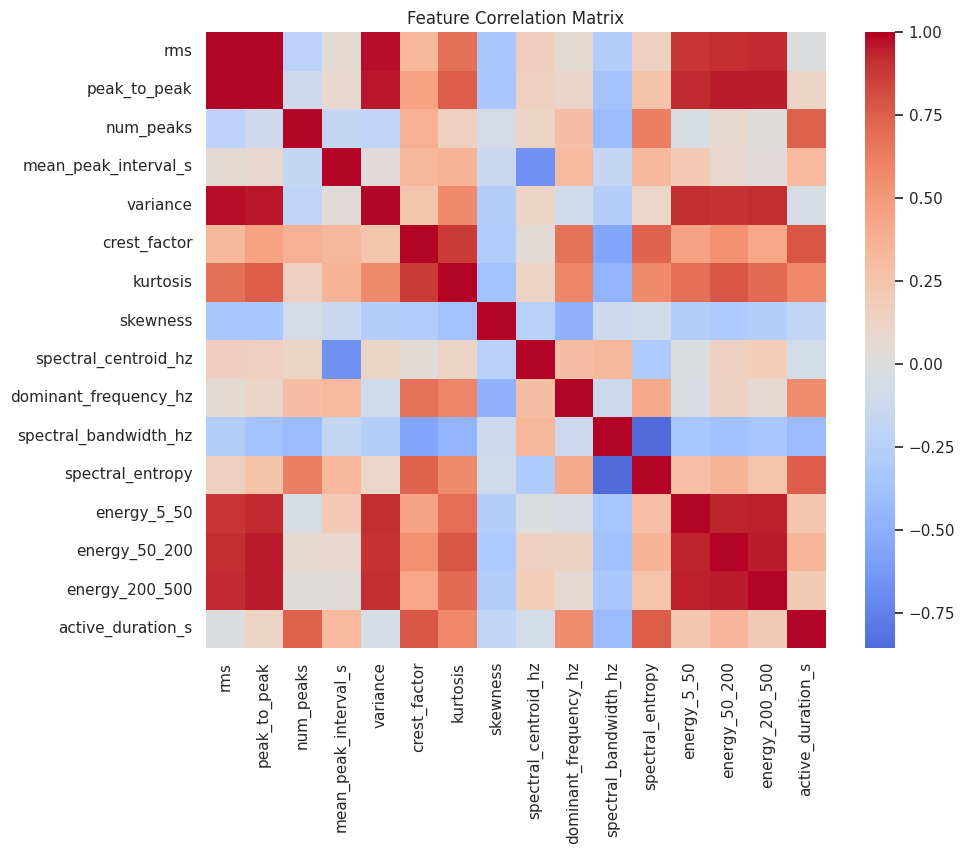

In [8]:
# ============================================================
# 7. Feature Exploration
# ============================================================

sns.pairplot(features_df.select_dtypes(np.number).dropna())
plt.show()

corr = features_df.select_dtypes(np.number).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()


In [18]:
corr = features_df.select_dtypes(np.number).corr()
corr

,rms,peak_to_peak,num_peaks,mean_peak_interval_s,variance,crest_factor,kurtosis,skewness,spectral_centroid_hz,dominant_frequency_hz,spectral_bandwidth_hz,spectral_entropy,energy_5_50,energy_50_200,energy_200_500,active_duration_s,cluster,speed_proxy
rms,1.000000,0.987558,-0.219160,0.049075,0.973107,0.336732,0.674449,-0.331501,0.171287,0.050998,-0.279659,0.145623,0.892062,0.915837,0.920378,-0.008074,-0.932886,-0.271925
peak_to_peak,0.987558,1.000000,-0.108359,0.082695,0.959845,0.453698,0.755891,-0.335748,0.162320,0.112321,-0.362727,0.258346,0.925858,0.954042,0.953768,0.124587,-0.925932,-0.312204
num_peaks,-0.219160,-0.108359,1.000000,-0.167482,-0.201920,0.378561,0.150637,-0.069383,0.130242,0.292944,-0.416147,0.620953,-0.041067,0.078190,0.011437,0.744637,0.194658,0.232306
mean_peak_interval_s,0.049075,0.082695,-0.167482,1.000000,0.028137,0.338076,0.365234,-0.144752,-0.652448,0.314930,-0.170253,0.326256,0.207848,0.084419,0.021760,0.318734,-0.023190,-0.886170
variance,0.973107,0.959845,-0.201920,0.028137,1.000000,0.242362,0.567079,-0.262352,0.130050,-0.100924,-0.259838,0.105378,0.916154,0.901280,0.915549,-0.049987,-0.983230,-0.190713
crest_factor,0.336732,0.453698,0.378561,0.338076,0.242362,1.000000,0.876794,-0.290977,0.037984,0.668693,-0.557695,0.732342,0.446527,0.541821,0.427979,0.787097,-0.204657,-0.593743
kurtosis,0.674449,0.755891,0.150637,0.365234,0.567079,0.876794,1.000000,-0.365765,0.125002,0.601295,-0.470711,0.570707,0.693029,0.782764,0.707048,0.584029,-0.515234,-0.629003
skewness,-0.331501,-0.335748,-0.069383,-0.144752,-0.262352,-0.290977,-0.365765,1.000000,-0.242484,-0.484259,-0.117137,-0.090525,-0.268991,-0.304027,-0.277346,-0.184730,0.195839,0.223980
spectral_centroid_hz,0.171287,0.162320,0.130242,-0.652448,0.130050,0.037984,0.125002,-0.242484,1.000000,0.291192,0.340532,-0.299326,-0.007718,0.145743,0.186601,-0.085901,-0.099757,0.486699
dominant_frequency_hz,0.050998,0.112321,0.292944,0.314930,-0.100924,0.668693,0.601295,-0.484259,0.291192,1.000000,-0.126651,0.414038,-0.029355,0.135208,0.056818,0.562259,0.182958,-0.495565


In [19]:
corr = features_df.select_dtypes(include=[np.number]).corr().abs()


In [20]:
upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))


In [33]:
threshold = 0.9

to_drop = [
    column
    for column in upper_tri.columns
    if any(upper_tri[column] > threshold)
]

print("Highly correlated features to drop:")
print(to_drop)


Highly correlated features to drop:
['peak_to_peak', 'variance', 'energy_5_50', 'energy_50_200', 'energy_200_500', 'cluster']


In [22]:
features_reduced = features_df.drop(columns=to_drop)


In [23]:
features_reduced.select_dtypes(np.number).corr()


,rms,num_peaks,mean_peak_interval_s,crest_factor,kurtosis,skewness,spectral_centroid_hz,dominant_frequency_hz,spectral_bandwidth_hz,spectral_entropy,active_duration_s,speed_proxy
rms,1.000000,-0.219160,0.049075,0.336732,0.674449,-0.331501,0.171287,0.050998,-0.279659,0.145623,-0.008074,-0.271925
num_peaks,-0.219160,1.000000,-0.167482,0.378561,0.150637,-0.069383,0.130242,0.292944,-0.416147,0.620953,0.744637,0.232306
mean_peak_interval_s,0.049075,-0.167482,1.000000,0.338076,0.365234,-0.144752,-0.652448,0.314930,-0.170253,0.326256,0.318734,-0.886170
crest_factor,0.336732,0.378561,0.338076,1.000000,0.876794,-0.290977,0.037984,0.668693,-0.557695,0.732342,0.787097,-0.593743
kurtosis,0.674449,0.150637,0.365234,0.876794,1.000000,-0.365765,0.125002,0.601295,-0.470711,0.570707,0.584029,-0.629003
skewness,-0.331501,-0.069383,-0.144752,-0.290977,-0.365765,1.000000,-0.242484,-0.484259,-0.117137,-0.090525,-0.184730,0.223980
spectral_centroid_hz,0.171287,0.130242,-0.652448,0.037984,0.125002,-0.242484,1.000000,0.291192,0.340532,-0.299326,-0.085901,0.486699
dominant_frequency_hz,0.050998,0.292944,0.314930,0.668693,0.601295,-0.484259,0.291192,1.000000,-0.126651,0.414038,0.562259,-0.495565
spectral_bandwidth_hz,-0.279659,-0.416147,-0.170253,-0.557695,-0.470711,-0.117137,0.340532,-0.126651,1.000000,-0.855033,-0.426920,0.276788
spectral_entropy,0.145623,0.620953,0.326256,0.732342,0.570707,-0.090525,-0.299326,0.414038,-0.855033,1.000000,0.754266,-0.422918


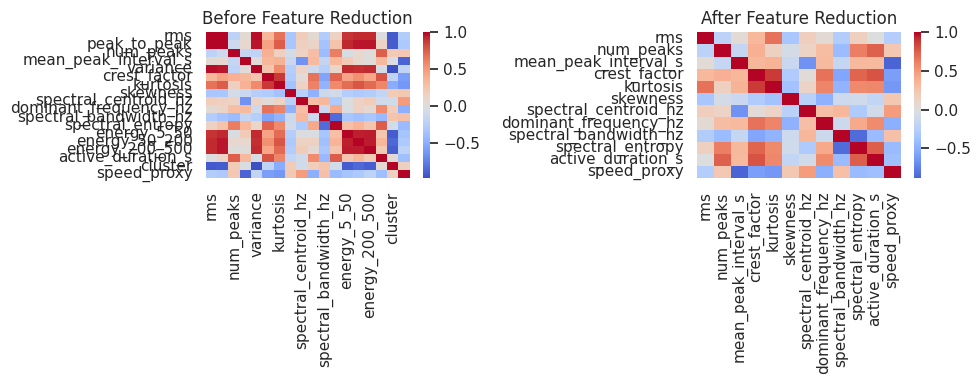

In [24]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(features_df.select_dtypes(np.number).corr(), cmap="coolwarm", center=0)
plt.title("Before Feature Reduction")

plt.subplot(1,2,2)
sns.heatmap(features_reduced.select_dtypes(np.number).corr(), cmap="coolwarm", center=0)
plt.title("After Feature Reduction")

plt.tight_layout()
plt.show()


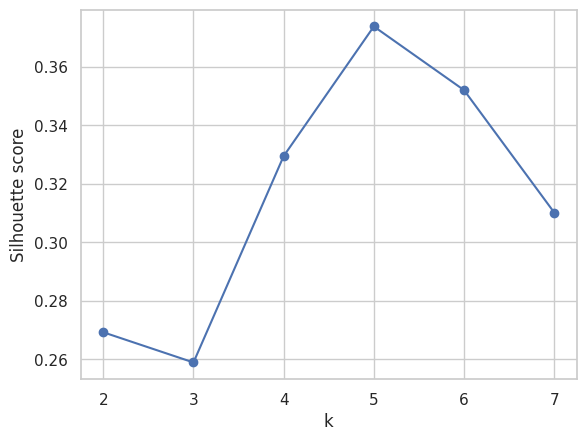

In [25]:
# ============================================================
# 8. Clustering (Silhouette + KMeans)
# ============================================================

X = features_reduced.select_dtypes(include=[np.number])
X = X.fillna(X.mean())
X_scaled = StandardScaler().fit_transform(X)

k_range = range(2, 8)
scores = []

for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.plot(k_range, scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(scores)]
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
features_reduced["cluster"] = kmeans.fit_predict(X_scaled)


InvalidParameterError: The 'labels' parameter of silhouette_samples must be an array-like. Got 5 instead.

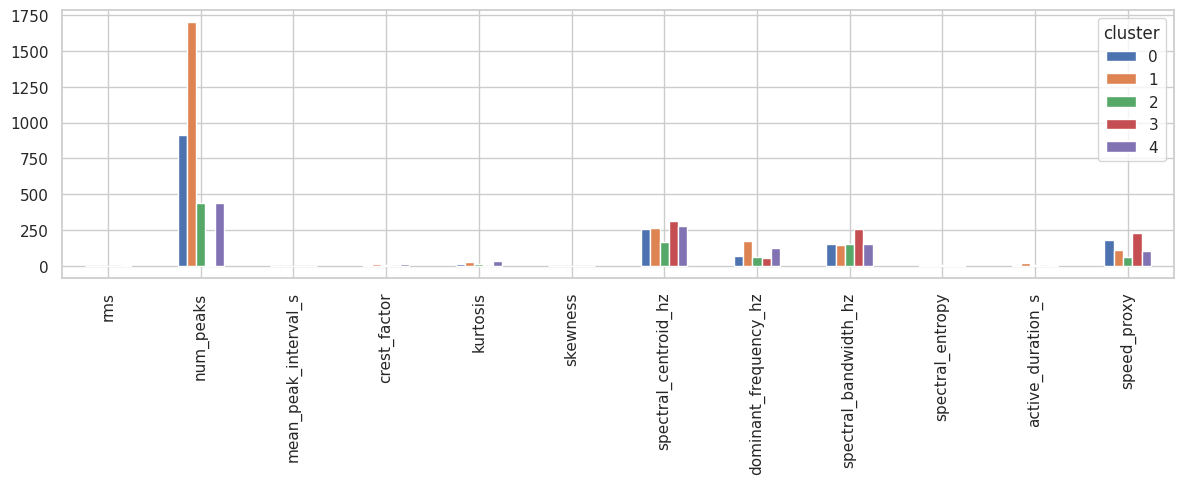

In [26]:
# ============================================================
# 10. Cluster Interpretation
# ============================================================

features_reduced.groupby("cluster").mean(numeric_only=True)

cluster_means = features_reduced.groupby("cluster").mean(numeric_only=True)
cluster_means.T.plot(kind="bar", figsize=(12,5))
plt.grid(True)
plt.tight_layout()
plt.show()


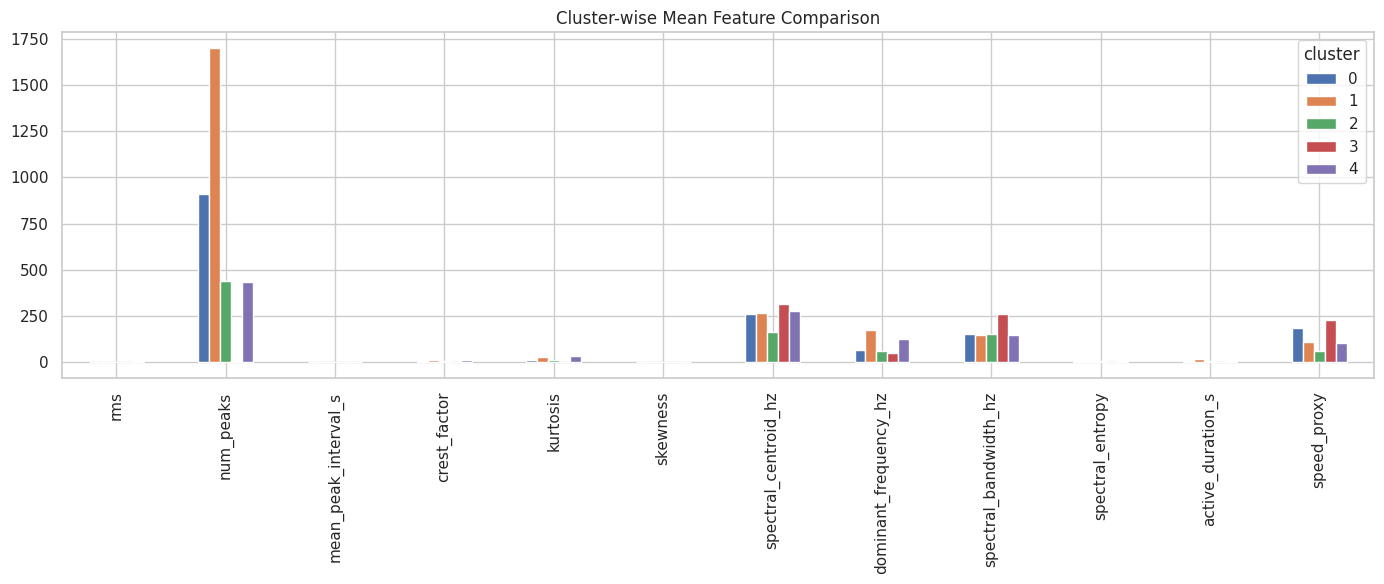

In [28]:
# ============================================================
# 10. Cluster Interpretation
# ============================================================

cluster_means = features_reduced.groupby("cluster").mean(numeric_only=True)
cluster_means.T.plot(kind="bar", figsize=(14,6))
plt.title("Cluster-wise Mean Feature Comparison")
plt.grid(True)
plt.tight_layout()
plt.show()


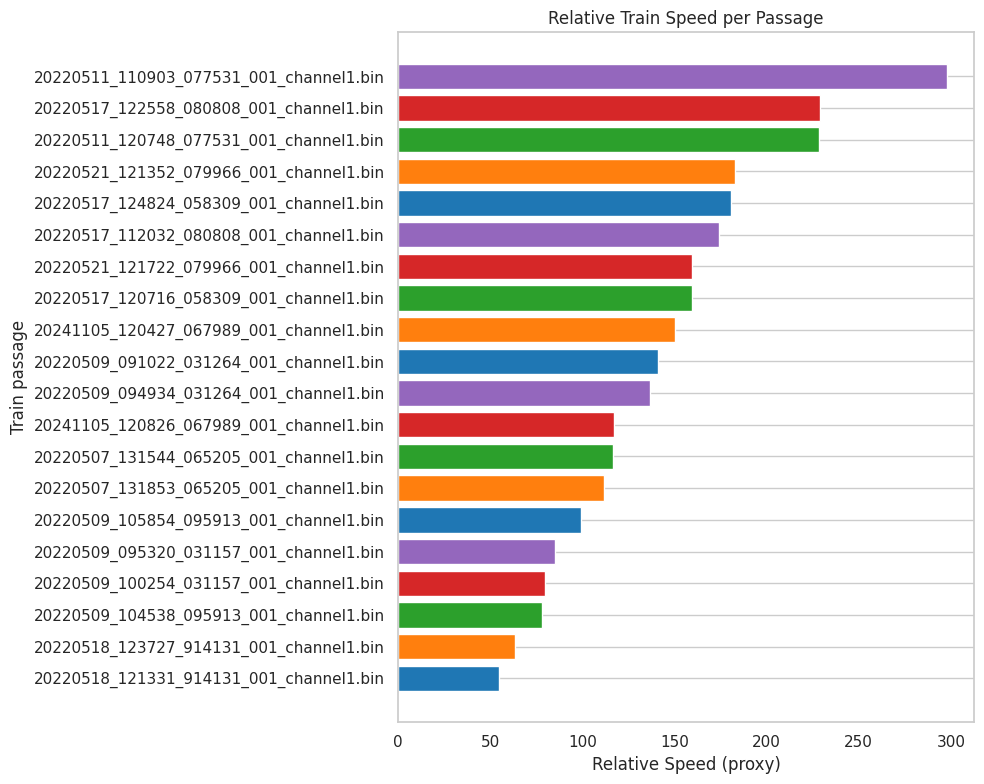

In [29]:
# ============================================================
# 11. Train Speed Estimation (Relative)
# ============================================================

features_reduced["speed_proxy"] = 1.0 / features_reduced["mean_peak_interval_s"]

features_df_sorted = features_reduced.sort_values("speed_proxy")

plt.figure(figsize=(10,8))
plt.barh(
    features_df_sorted.index,
    features_df_sorted["speed_proxy"],
    color=sns.color_palette("tab10", features_df_sorted["cluster"].nunique()),
)
plt.xlabel("Relative Speed (proxy)")
plt.ylabel("Train passage")
plt.title("Relative Train Speed per Passage")
plt.grid(axis="x")
plt.tight_layout()
plt.show()
